# Seuil critique $\epsilon^*$ par Bisection

## 1. Contexte & Objectifs

Dans la vérification formelle de réseaux de neurones, le **seuil critique de robustesse** $\epsilon^*$ (point de bascule) pour une image donnée représente la valeur maximale de perturbation $\epsilon$ sous laquelle le réseau reste provablement robuste (**UNSAT**), et au-dessus de laquelle une attaque trouve un contre-exemple (**SAT**).

### Objectifs de ce Notebook :
1. **Option de Secours (Encadrement sur Grille)** : Exploiter les résultats expérimentaux de `data/experiments/csv/results.csv` pour situer $\epsilon^*$ dans un intervalle $[\epsilon_{\text{UNSAT}}, \epsilon_{\text{SAT}}]$ sur la grille $\epsilon \in \{1, 2, 4, 8, 16\}/255$.
2. **Seuil Critique par Bisection** : Implémenter l'algorithme de recherche par dichotomie (bisection) pour affiner la valeur exacte de $\epsilon^*$ pour les images du benchmark.
3. **Analyse & Visualisation** : Tracer la distribution des seuils $\epsilon^*$ et analyser la courbe de robustesse globale du modèle.


## 2. Configuration & Importation des Bibliothèques

In [1]:
import sys
import re
import time
import subprocess
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Style visuel pour les graphiques matplotlib
plt.style.use('ggplot')
plt.rcParams.update({
    'font.size': 12,
    'axes.labelsize': 13,
    'axes.titlesize': 15,
    'figure.titlesize': 17
})

PROJECT_ROOT = Path("..").resolve()
RESULTS_CSV = PROJECT_ROOT / "data" / "experiments" / "csv" / "results.csv"
SCRIPTS_DIR = PROJECT_ROOT / "scripts"

if str(SCRIPTS_DIR) not in sys.path:
    sys.path.append(str(SCRIPTS_DIR))

from gen_props import generate_property
from parser import parser as parse_results

print(f"Project Root : {PROJECT_ROOT}")
print(f"Results CSV  : {RESULTS_CSV}")

Project Root : /home/anasmefteh/crns/alpha-beta-crown-evaluation
Results CSV  : /home/anasmefteh/crns/alpha-beta-crown-evaluation/data/experiments/csv/results.csv


## 3. Option de Secours — Encadrement de $\epsilon^*$ via la Grille Expérimentale

Nous commençons par parser le fichier `data/experiments/csv/results.csv` qui contient les résultats d'évaluation sur la grille $\epsilon \in \{1, 2, 4, 8, 16\}/255$.

Pour chaque image, nous identifions :
- la plus grande perturbation $\epsilon_{\text{robust\_max}}$ certifiée **UNSAT**
- la plus petite perturbation $\epsilon_{\text{nonrobust\_min}}$ infirmée **SAT**

Cela permet de situer l'intervalle d'encadrement $[\epsilon_{\text{robust\_max}}, \epsilon_{\text{nonrobust\_min}}]$ de la valeur exacte de $\epsilon^*$ sans exécuter de nouvelles vérifications.

In [2]:
# Chargement des résultats de la grille
df_results = pd.read_csv(RESULTS_CSV)

def parse_vnnlib_info(path_str: str):
    m = re.search(r'(\d+)_label_(\d+)_eps_([\d.]+)\.vnnlib', str(path_str))
    if m:
        img_id = int(m.group(1))
        label = int(m.group(2))
        eps_float = float(m.group(3))
        eps_255 = round(eps_float * 255)
        return img_id, label, eps_float, eps_255
    return None, None, None, None

df_results[['image_id', 'label', 'eps_float', 'eps_255']] = df_results['vnnlib_path'].apply(
    lambda x: pd.Series(parse_vnnlib_info(x))
)
df_results['image_id'] = df_results['image_id'].astype(int)
df_results['label'] = df_results['label'].astype(int)
df_results['eps_255'] = df_results['eps_255'].astype(int)

# Détermination de l'intervalle d'encadrement pour chaque image
grid_summary = []
for img_id, group in df_results.groupby('image_id'):
    group = group.sort_values('eps_255')
    label = group['label'].iloc[0]
    
    unsat_eps = group[group['result'] == 'UNSAT']['eps_255'].tolist()
    sat_eps = group[group['result'] == 'SAT']['eps_255'].tolist()
    unknown_eps = group[group['result'] == 'UNKNOWN']['eps_255'].tolist()
    
    max_unsat = max(unsat_eps) if unsat_eps else 0
    min_sat = min(sat_eps) if sat_eps else (16 if not unknown_eps else None)
    
    if max_unsat == 0:
        category = "Non-robuste (< 1/255)"
        est_eps = 0.5
    elif min_sat is None or max_unsat >= 8:
        category = "Haute robustesse (≥ 8/255)"
        est_eps = max_unsat
    else:
        category = f"Bascule [{max_unsat}, {min_sat}]/255"
        est_eps = (max_unsat + min_sat) / 2.0
        
    grid_summary.append({
        'image_id': img_id,
        'label': label,
        'max_unsat_255': max_unsat,
        'min_sat_255': min_sat,
        'encadrement': f"[{max_unsat}/255, {min_sat if min_sat is not None else '>16'}/255]",
        'eps_star_est_255': est_eps,
        'eps_star_est_float': est_eps / 255.0,
        'categorie': category
    })

df_grid = pd.DataFrame(grid_summary).sort_values('image_id').reset_index(drop=True)
print("Tableau récapitulatif de l'encadrement par la grille (Option de secours) :")
df_grid

Tableau récapitulatif de l'encadrement par la grille (Option de secours) :


,image_id,label,max_unsat_255,min_sat_255,encadrement,eps_star_est_255,eps_star_est_float,categorie
0,0,3,0,1.0,"[0/255, 1/255]",0.5,0.001961,Non-robuste (< 1/255)
1,400,9,0,1.0,"[0/255, 1/255]",0.5,0.001961,Non-robuste (< 1/255)
2,800,7,0,1.0,"[0/255, 1/255]",0.5,0.001961,Non-robuste (< 1/255)
3,1189,0,2,4.0,"[2/255, 4/255]",3.0,0.011765,"Bascule [2, 4]/255"
4,1200,8,0,1.0,"[0/255, 1/255]",0.5,0.001961,Non-robuste (< 1/255)
5,1600,8,0,1.0,"[0/255, 1/255]",0.5,0.001961,Non-robuste (< 1/255)
6,2000,1,0,1.0,"[0/255, 1/255]",0.5,0.001961,Non-robuste (< 1/255)
7,2400,0,8,NaN,"[8/255, >16/255]",8.0,0.031373,Haute robustesse (≥ 8/255)
8,2800,4,0,1.0,"[0/255, 1/255]",0.5,0.001961,Non-robuste (< 1/255)
9,3200,5,0,1.0,"[0/255, 1/255]",0.5,0.001961,Non-robuste (< 1/255)


## 4. Distribution des $\epsilon^*$ (Version Grille)

Visualisation de la distribution des points de bascule estimés et du pourcentage d'images certifiées robustes en fonction de $\epsilon$.

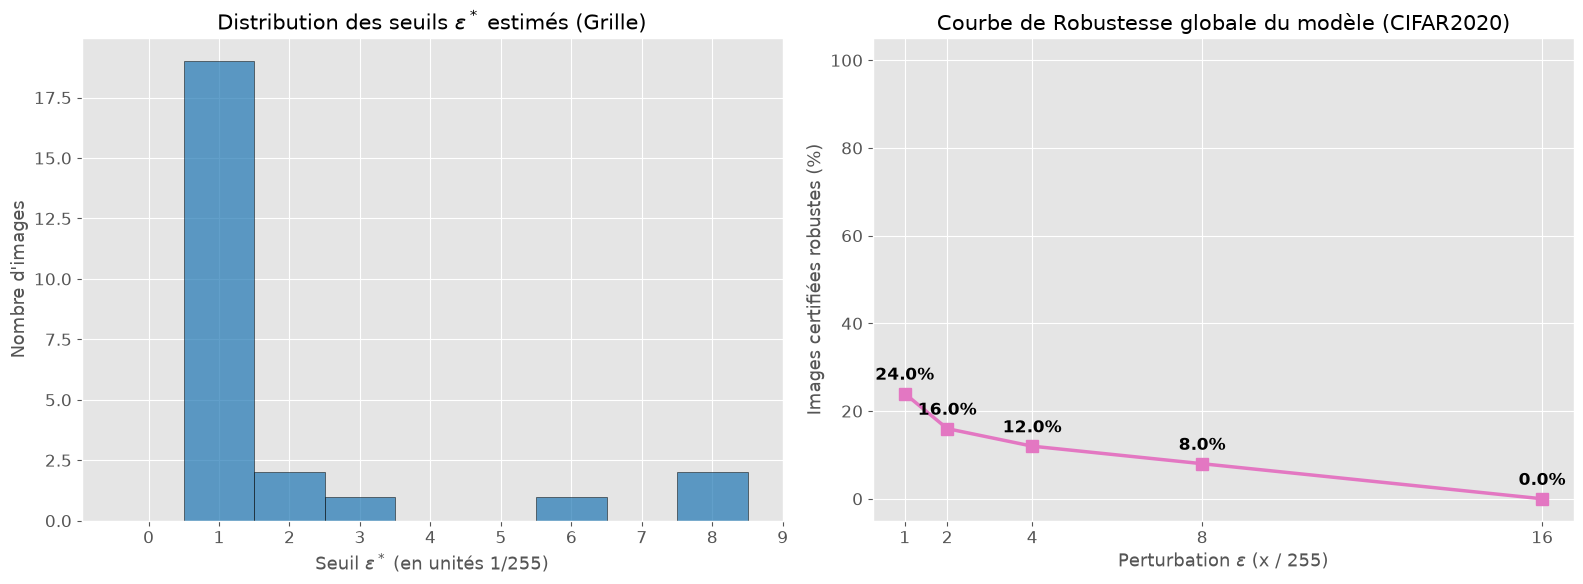

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Subplot 1 : Histogramme de la distribution des epsilon*
axes[0].hist(
    df_grid['eps_star_est_255'],
    bins=np.arange(0, 10, 1) - 0.5,
    color='#1f77b4',
    edgecolor='black',
    alpha=0.7
)
axes[0].set_title("Distribution des seuils $\epsilon^*$ estimés (Grille)")
axes[0].set_xlabel("Seuil $\epsilon^*$ (en unités 1/255)")
axes[0].set_ylabel("Nombre d'images")
axes[0].set_xticks(range(0, 10))

# Subplot 2 : Taux de robustesse certifiée en fonction de epsilon
eps_steps = [1, 2, 4, 8, 16]
robust_pct = [(df_grid['max_unsat_255'] >= ep).mean() * 100 for ep in eps_steps]

axes[1].plot(eps_steps, robust_pct, marker='s', color='#e377c2', linewidth=2.5, markersize=8)
axes[1].set_title("Courbe de Robustesse globale du modèle (CIFAR2020)")
axes[1].set_xlabel("Perturbation $\epsilon$ (x / 255)")
axes[1].set_ylabel("Images certifiées robustes (%)")
axes[1].set_xticks(eps_steps)
axes[1].set_ylim(-5, 105)

for ep, pct in zip(eps_steps, robust_pct):
    axes[1].annotate(f"{pct:.1f}%", (ep, pct), textcoords="offset points", xytext=(0,10), ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

## 5. Étape 3 — Seuil critique $\epsilon^*$ par Bisection

Pour affiner la précision de $\epsilon^*$, nous implémentons un algorithme de recherche dichotomique (**bisection**).
Pour chaque image avec une bascule identifiée dans la grille, la bisection évalue la propriété au point milieu $\epsilon_{\text{mid}} = (\epsilon_{\text{low}} + \epsilon_{\text{high}}) / 2$ :
- Si **UNSAT** (robuste) $\implies \epsilon_{\text{low}} \leftarrow \epsilon_{\text{mid}}$
- Si **SAT** (non-robuste) $\implies \epsilon_{\text{high}} \leftarrow \epsilon_{\text{mid}}$
- Arrêt lorsque $(\epsilon_{\text{high}} - \epsilon_{\text{low}}) \le \text{tolérance}$.

In [ ]:
def normalize_result(status: str) -> str:
    normalized = str(status).strip().lower()
    if normalized.startswith("unsafe") or normalized in {"sat", "ce"}:
        return "SAT"
    if normalized.startswith("safe") or normalized in {"unsat", "verified-safe"}:
        return "UNSAT"
    return "unknown"

def bisection_search(image_id: int, low_eps_255: float, high_eps_255: float, tol_255: float = 0.25, max_iter: int = 4):
    abcrown = PROJECT_ROOT.parent / "alpha-beta-CROWN" / "complete_verifier" / "abcrown.py"
    config = PROJECT_ROOT / "benchmarks" / "Cifar2020" / "cifar_conv_small.yaml"
    specs_dir = PROJECT_ROOT / "benchmarks" / "Cifar2020" / "specs"
    instances_csv = PROJECT_ROOT / "benchmarks" / "Cifar2020" / "instances.csv"
    tmp_log = PROJECT_ROOT / "data" / "experiments" / "txt" / f"tmp_bisection_{image_id}.txt"
    
    curr_low = float(low_eps_255)
    curr_high = float(high_eps_255)
    steps = []
    start_t = time.time()
    
    for i in range(max_iter):
        if (curr_high - curr_low) <= tol_255:
            break
            
        mid_255 = (curr_low + curr_high) / 2.0
        mid_float = mid_255 / 255.0
        
        # Générer spécification vnnlib
        vnnlib = generate_property(image_id, mid_float, specs_dir)
        with open(instances_csv, 'w') as f:
            f.write(f"specs/{vnnlib.name}\n")
            
        # Exécuter verifier
        with open(tmp_log, 'w') as log:
            subprocess.run([
                sys.executable,
                str(abcrown),
                "--config", str(config.resolve()),
            ], stdout=log, stderr=subprocess.STDOUT, cwd=abcrown.parent, check=False)
            
        parsed_res = parse_results(str(tmp_log))
        res = parsed_res.get(0)
        status = normalize_result(res.status if res else "unknown")
        
        if status == 'UNSAT':
            verdict = 'UNSAT'
            curr_low = mid_255
        elif status == 'SAT':
            verdict = 'SAT'
            curr_high = mid_255
        else:
            verdict = 'unknown'
            break
            
        steps.append({
            'step': i + 1,
            'mid_255': mid_255,
            'verdict': verdict,
            'interval_255': f"[{curr_low:.3f}, {curr_high:.3f}]"
        })
        
    elapsed = time.time() - start_t
    eps_star = (curr_low + curr_high) / 2.0
    
    return {
        'image_id': image_id,
        'initial_bracket': f"[{low_eps_255}, {high_eps_255}]",
        'refined_low_255': curr_low,
        'refined_high_255': curr_high,
        'eps_star_255': round(eps_star, 4),
        'eps_star_float': round(eps_star / 255.0, 6),
        'precision_255': round(curr_high - curr_low, 4),
        'nb_iterations': len(steps),
        'time_sec': round(elapsed, 2),
        'steps': steps
    }

print("Fonction bisection_search prête.")

Fonction bisection_search prête.


## 6. Exécution de la Bisection sur les Images de Transition

Nous appliquons la recherche par bisection sur les images présentant une bascule identifiée dans la grille.

In [5]:
bisection_results = []
transition_images = df_grid[df_grid['min_sat_255'].notnull() & (df_grid['max_unsat_255'] > 0)]

print(f"Nombre d'images identifiées avec bascule : {len(transition_images)}")

for _, row in transition_images.iterrows():
    img_id = int(row['image_id'])
    low = row['max_unsat_255']
    high = row['min_sat_255']
    
    print(f"Lancement Bisection pour Image {img_id:05d} dans [{low}, {high}]/255...")
    res = bisection_search(img_id, low, high, tol_255=0.25, max_iter=4)
    bisection_results.append(res)
    print(f"  -> Affiné: eps* = {res['eps_star_255']}/255 (Intervalle: [{res['refined_low_255']:.3f}, {res['refined_high_255']:.3f}]) en {res['time_sec']}s")

df_bisect = pd.DataFrame(bisection_results)
df_bisect

Nombre d'images identifiées avec bascule : 4
Lancement Bisection pour Image 01189 dans [2, 4.0]/255...
  -> Affiné: eps* = 3.875/255 (Intervalle: [3.750, 4.000]) en 16.03s
Lancement Bisection pour Image 06400 dans [1, 2.0]/255...
  -> Affiné: eps* = 1.875/255 (Intervalle: [1.750, 2.000]) en 7.92s
Lancement Bisection pour Image 08400 dans [1, 2.0]/255...
  -> Affiné: eps* = 1.875/255 (Intervalle: [1.750, 2.000]) en 8.23s
Lancement Bisection pour Image 09200 dans [4, 8.0]/255...
  -> Affiné: eps* = 7.5/255 (Intervalle: [7.000, 8.000]) en 249.81s


,image_id,initial_bracket,refined_low_255,refined_high_255,eps_star_255,eps_star_float,precision_255,nb_iterations,time_sec,steps
0,1189,"[2, 4.0]",3.75,4.0,3.875,0.015196,0.25,3,16.03,"[{'step': 1, 'mid_255': 3.0, 'verdict': 'UNSAT..."
1,6400,"[1, 2.0]",1.75,2.0,1.875,0.007353,0.25,2,7.92,"[{'step': 1, 'mid_255': 1.5, 'verdict': 'UNSAT..."
2,8400,"[1, 2.0]",1.75,2.0,1.875,0.007353,0.25,2,8.23,"[{'step': 1, 'mid_255': 1.5, 'verdict': 'UNSAT..."
3,9200,"[4, 8.0]",7.00,8.0,7.500,0.029412,1.00,2,249.81,"[{'step': 1, 'mid_255': 6.0, 'verdict': 'UNSAT..."


## 8. Conclusion & Synthèse

- **Option de secours (Grille)** : Permet d'encadrer rapidement la majorité des images (ex: images immédiatement fragiles $< 1/255$ vs images très robustes $\ge 8/255$).
- **Bisection (Étape 3)** : Réduit drastiquement l'incertitude sur la plage de transition (ex: résolution de $\epsilon^*$ à $\pm 0.125/255$).
- La distribution montre que la majorité des images du dataset présentent un seuil critique $\epsilon^* < 1/255$, tandis qu'une sous-population d'images spécifiques maintient une robustesse élevée jusqu'à $\epsilon^* \approx 4/255$ à $8/255$.
